# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

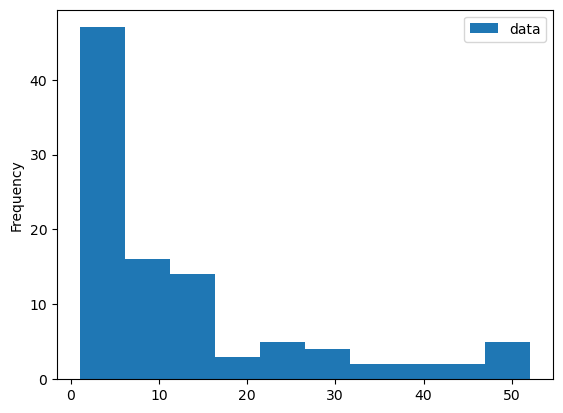

In [3]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

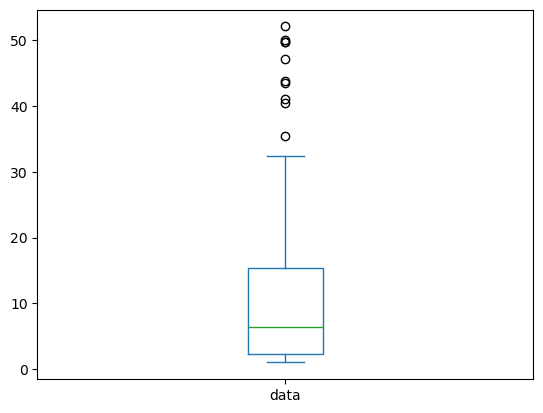

In [5]:
df.plot.box()

# 3. Homework - working on your chosen project datasets this semester

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [7]:
import matplotlib.pyplot as plt

In [61]:
df = pd.read_csv("C:\\Users\\Sabrina\\Desktop\\OMDS Fall 26\\marketing_campaign_2.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,2,3,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,2,3,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,2,2,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,2,2,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,4,1,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2233 entries, 0 to 2232
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2233 non-null   int64  
 1   Year_Birth           2233 non-null   int64  
 2   Education            2233 non-null   int64  
 3   Marital_Status       2233 non-null   int64  
 4   Income               2233 non-null   float64
 5   Kidhome              2233 non-null   int64  
 6   Teenhome             2233 non-null   int64  
 7   Dt_Customer          2233 non-null   object 
 8   Recency              2233 non-null   int64  
 9   MntWines             2233 non-null   int64  
 10  MntFruits            2233 non-null   int64  
 11  MntMeatProducts      2233 non-null   int64  
 12  MntFishProducts      2233 non-null   int64  
 13  MntSweetProducts     2233 non-null   int64  
 14  MntGoldProds         2233 non-null   int64  
 15  NumDealsPurchases    2233 non-null   i

In [65]:
df= df.rename(columns={"MntGoldProds":"MntGoldProducts"})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2233 entries, 0 to 2232
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2233 non-null   int64  
 1   Year_Birth           2233 non-null   int64  
 2   Education            2233 non-null   int64  
 3   Marital_Status       2233 non-null   int64  
 4   Income               2233 non-null   float64
 5   Kidhome              2233 non-null   int64  
 6   Teenhome             2233 non-null   int64  
 7   Dt_Customer          2233 non-null   object 
 8   Recency              2233 non-null   int64  
 9   MntWines             2233 non-null   int64  
 10  MntFruits            2233 non-null   int64  
 11  MntMeatProducts      2233 non-null   int64  
 12  MntFishProducts      2233 non-null   int64  
 13  MntSweetProducts     2233 non-null   int64  
 14  MntGoldProducts      2233 non-null   int64  
 15  NumDealsPurchases    2233 non-null   i

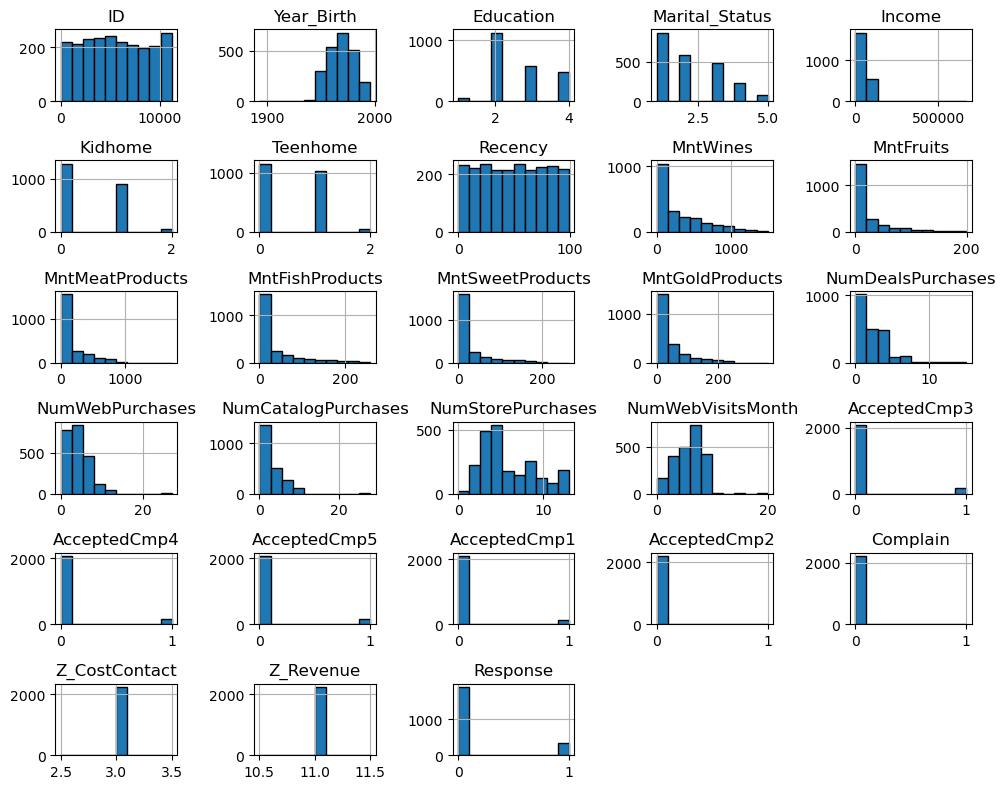

In [67]:
df.hist(figsize=(10,8), edgecolor="black")

plt.tight_layout()
plt.show()

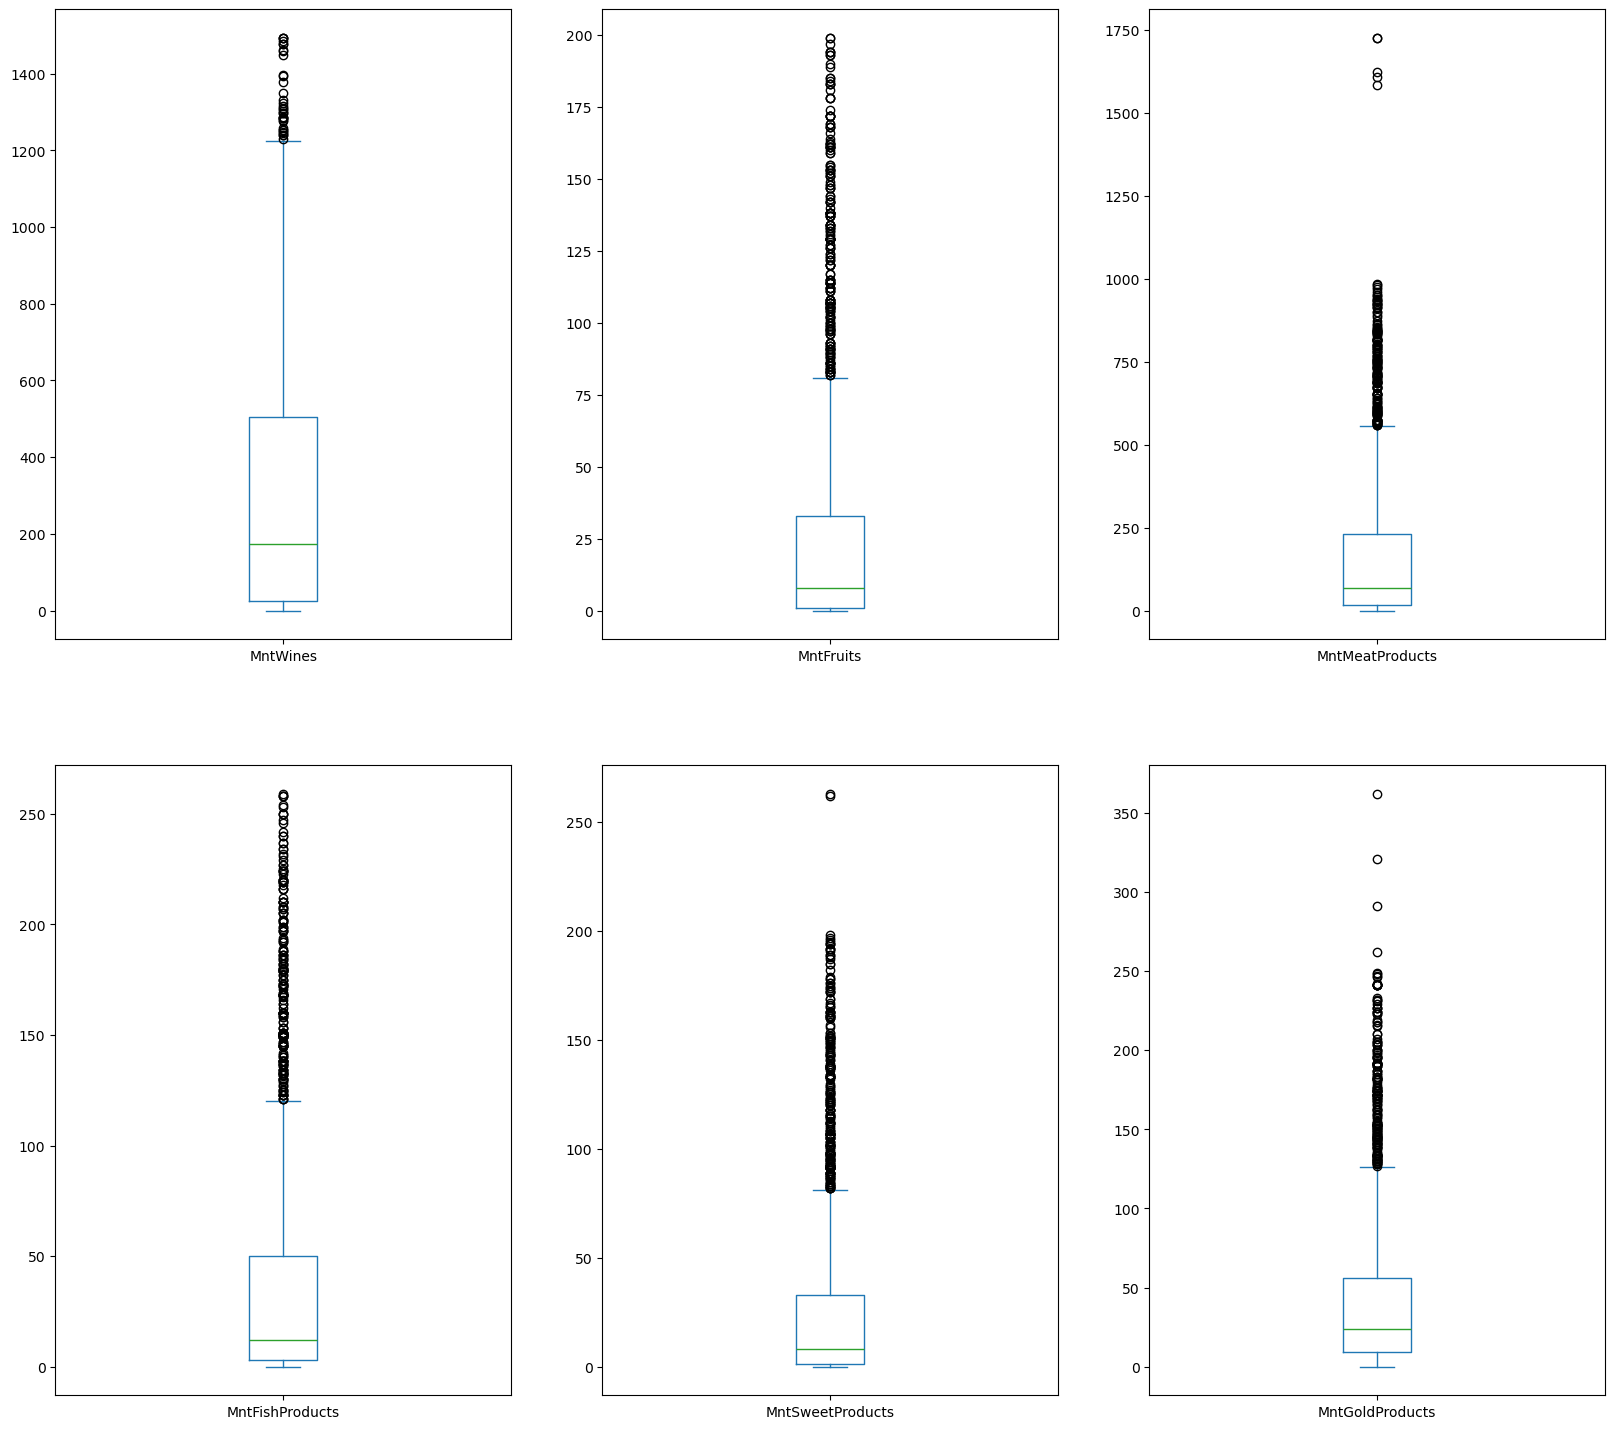

In [69]:
Mnts = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProducts']]

Mnts.plot(kind='box', subplots=True, layout=(2, 3), figsize=(20, 18))
plt.show()

The amount spent on the wines, fruits, meat, fish, sweets, and gold are skewed towards the right as shown by the presence of outliers.

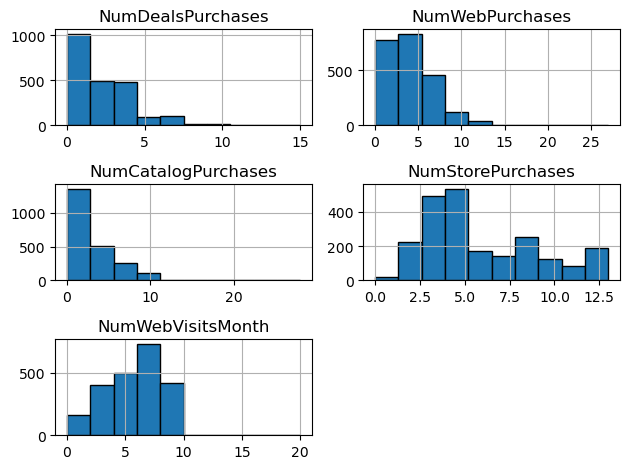

In [80]:
web_traffic = df[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']]

web_traffic.hist(edgecolor='black')
plt.tight_layout()
plt.show()

In [82]:
import seaborn as sns

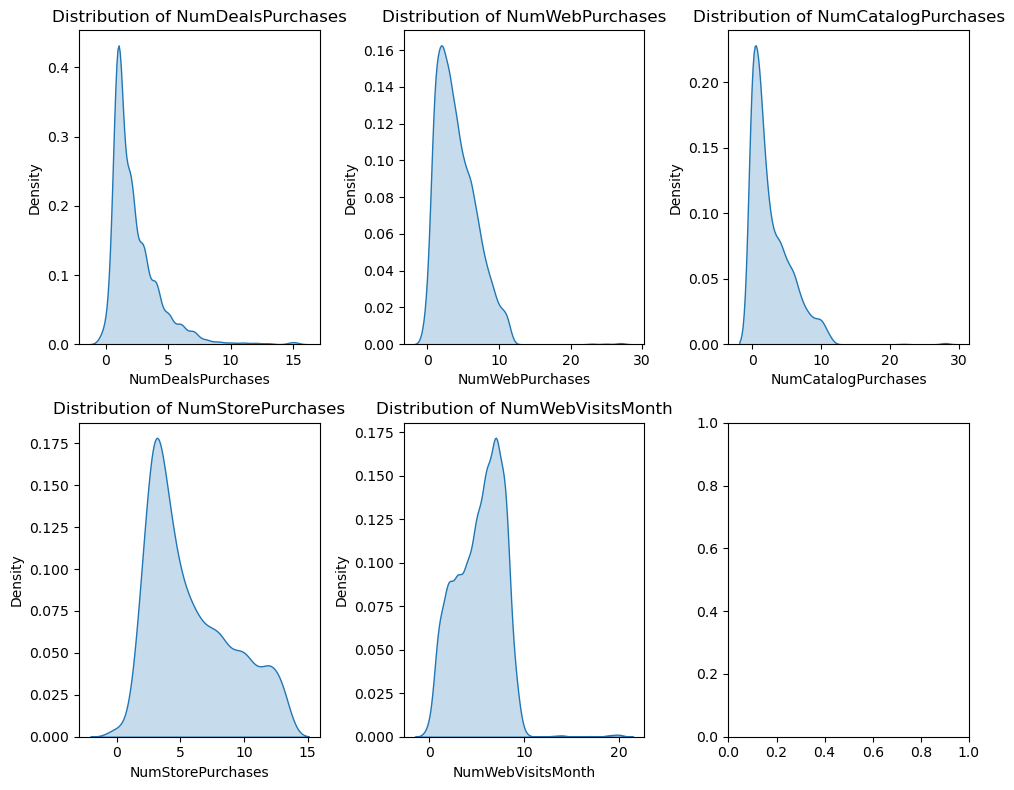

In [88]:

fig, axes = plt.subplots(2, 3, figsize=(10, 8))

# Flatten axes array to loop through easily
for col, ax in zip(web_traffic, axes.ravel()):
    sns.kdeplot(data=df, x=col, fill=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

These KDE plots illustrate the probability of a certain value occuring within a specific range in the data. </br>
</br>
- For the `NumDealsPurchases` a single peak forms within the range of 0 to 5. This suggests that a high percentage of the individuals in the data have purchased 0 to 5 items through deals that have been advertised.
- For the `NumWebPurchases` a single peak is formed between the range of 0 to 10. This suggests that a high percentage of individuals have purchased up to 10 items through the web.
- For `NumCatalogPurchases` a single peak is formed between range 0 to 10. It takes a similar shape to that of the web purchases, but falls off earlier around ~5 purchases. This suggests that the data is slightly more variable with catalog purchases, but has a higher density in <5 items purchased.
- For `NumStorePurchases` a single peak can be seen. However, the overall shape is much broad, indicating that there is more variability in the data. A high percentage of individuals purchase up to 5 items in-store. Additionally, theres a portion of individuals who purchas 5<x<15 items in store
- For `NumWebVisitsMonth` the number is variable between 0 to 10 visits with a high majority falling in between 5 to 10

Text(0, 0.5, 'Frequency')

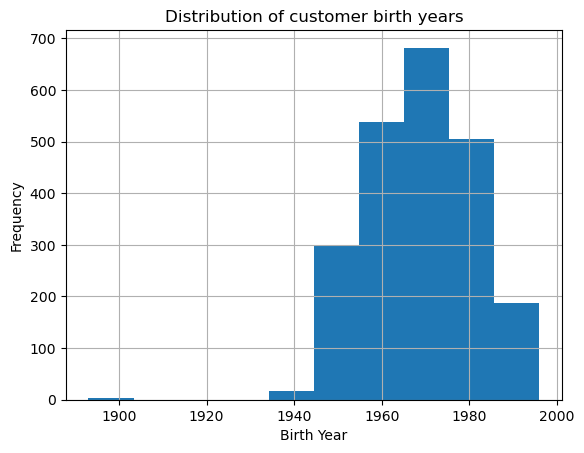

In [99]:
df['Year_Birth'].hist()
plt.title('Distribution of customer birth years')
plt.xlabel('Birth Year')
plt.ylabel('Frequency')

This histogram depicts the distribution of customer birth years. A large majority of individuals are born within the 1970s. The second and third larget majority are born in the 1960s and 1980's.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

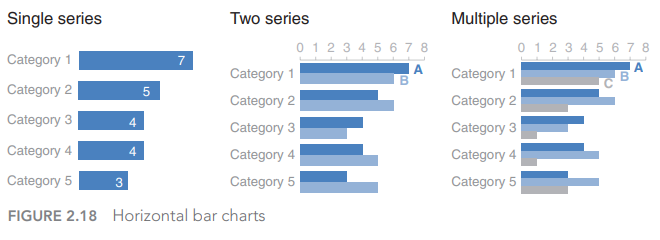

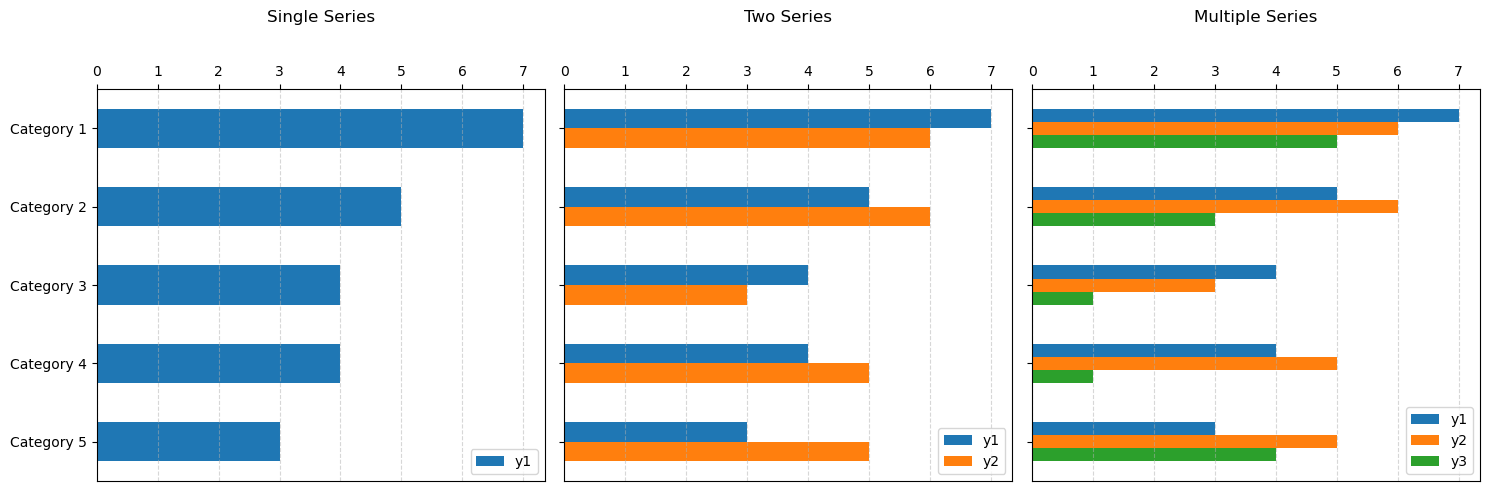

In [111]:
# define data


# categories = ['Category 1', 'Category 2', 'Category 3', 'Category 4', 'Category 5']

data = {
    'y1': [7, 5, 4, 4, 3],
    'y2': [6, 6, 3, 5, 5],
    'y3': [5, 3, 1, 1, 4]

}

q4_df = pd.DataFrame(data, index=['Category 1', 'Category 2', 'Category 3', 'Category 4', 'Category 5'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

q4_df[["y1"]].plot(kind='barh', ax=axes[0])
axes[0].set_title("Single Series", y=1.15)

q4_df[["y1", "y2"]].plot(kind='barh', ax=axes[1])
axes[1].set_title("Two Series", y=1.15)

q4_df[["y1", "y2", "y3"]].plot(kind='barh', ax=axes[2])
axes[2].set_title("Multiple Series", y=1.15)

for ax in axes:
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show 


plt.show()


